# Análisis Exploratorio de Datos (EDA)

Notebook para realizar el análisis exploratorio de datos (EDA) del dataset de señales ECG. Este análisis nos permitirá comprender mejor la estructura de los datos, identificar patrones y detectar posibles anomalías.

###  Cargar Dataset y Líbrerías
Para empezar, cargamos el dataset de `./data/mitbih_train.csv` y `./data/mitbih_test.csv` utilizando la librería `pandas`. También importamos las librerías necesarias para el análisis y visualización de datos.

In [82]:
# Cargar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# set seed
np.random.seed(42)

In [83]:
data_train = pd.read_csv('..\data\mitbih_train.csv', header=None)
data_test = pd.read_csv('..\data\mitbih_test.csv', header=None)
print("Datasets cargados correctamente.")

Datasets cargados correctamente.


In [84]:
col_names = [f"t{i}" for i in range(187)] + ["label"]
data_train.columns = col_names
data_test.columns  = col_names

data_train["label"] = data_train["label"].astype(int)
data_test["label"]  = data_test["label"].astype(int)

### Información General y Valores Nulos
Una vez cargado el dataset, revisamos su estructura general, incluyendo la identificación de valores nulos.

In [85]:
# Shape
print("Shape del dataset de entrenamiento:", data_train.shape)
print("Shape del dataset de prueba:", data_test.shape)

Shape del dataset de entrenamiento: (87554, 188)
Shape del dataset de prueba: (21892, 188)


In [86]:
# Aspecto de los datos
print("Primeras filas y columnas del dataset de entrenamiento:")
print(data_train.iloc[:5, :5])
print("\nPrimeras filas y columnas del dataset de prueba:")
print(data_test.iloc[:5, :5])

Primeras filas y columnas del dataset de entrenamiento:
         t0        t1        t2        t3        t4
0  0.977941  0.926471  0.681373  0.245098  0.154412
1  0.960114  0.863248  0.461538  0.196581  0.094017
2  1.000000  0.659459  0.186486  0.070270  0.070270
3  0.925414  0.665746  0.541436  0.276243  0.196133
4  0.967136  1.000000  0.830986  0.586854  0.356808

Primeras filas y columnas del dataset de prueba:
         t0        t1        t2        t3        t4
0  1.000000  0.758264  0.111570  0.000000  0.080579
1  0.908425  0.783883  0.531136  0.362637  0.366300
2  0.730088  0.212389  0.000000  0.119469  0.101770
3  1.000000  0.910417  0.681250  0.472917  0.229167
4  0.570470  0.399329  0.238255  0.147651  0.000000


In [87]:
# Valores nulos
x = data_train.isnull().sum().sum()
y = data_test.isnull().sum().sum()

if x == 0 and y == 0:
    print("No hay valores nulos en ninguno de los datasets.")
else:
    print(f"Hay {x} valores nulos en el dataset de entrenamiento y {y} en el dataset de prueba.")

No hay valores nulos en ninguno de los datasets.


In [88]:
# Rango de valores
print(f"Rango señal: [{data_train.iloc[:, :187].min().min():.4f}, {data_train.iloc[:, :187].max().max():.4f}]")
print(f"\nRango señal (test): [{data_test.iloc[:, :187].min().min():.4f}, {data_test.iloc[:, :187].max().max():.4f}]")


Rango señal: [0.0000, 1.0000]

Rango señal (test): [0.0000, 1.0000]


Podemos ver que el dataset tanto de entrenamiento como de prueba contiene 187 columnas de señales y una columna de etiquetas que contiene numeros enteros del 0 al 4, representando diferentes tipos de latidos cardíacos.
0. Normal
1. Supraventricular
2. Ventricular
3. Fusión
4. Desconocido

A parte, hemos podido ver que el rango de valores de las señales oscila entre 0 y 1, lo que sugiere que los datos ya han sido normalizados. Los datos vienen limpios, libres de valores nulos, lo que facilita el proceso de análisis y modelado posterior.

A continuación, profundizamos en la distribución de las clases y la visualización de las señales ECG para cada tipo de latido cardíaco. Esto nos ayudará a entender mejor las características de cada clase y a identificar posibles desafíos para el modelado.

### Distribución de Clases

En un dataset de clasificación, es crucial entender la distribución de las clases para identificar posibles desequilibrios que puedan afectar el rendimiento del modelo. En este caso, analizamos la distribución de las clases en el dataset de entrenamiento para cada tipo de latido cardíaco.

In [89]:
class_names = {0: "Normal", 1: "Supraventricular", 2: "Ventricular", 3: "Fusion", 4: "Desconocido"}

train_counts = data_train["label"].value_counts().sort_index()
test_counts  = data_test["label"].value_counts().sort_index()

dist = pd.DataFrame({
    "Clase": [class_names[i] for i in train_counts.index],
    "Train (n)": train_counts.values,
    "Train (%)": (train_counts.values / len(data_train) * 100).round(2),
    "Test (n)":  test_counts.values,
    "Test (%)":  (test_counts.values / len(data_test) * 100).round(2),
})
dist.index = train_counts.index
print(dist.to_string())

                  Clase  Train (n)  Train (%)  Test (n)  Test (%)
label                                                            
0                Normal      72471      82.77     18118     82.76
1      Supraventricular       2223       2.54       556      2.54
2           Ventricular       5788       6.61      1448      6.61
3                Fusion        641       0.73       162      0.74
4           Desconocido       6431       7.35      1608      7.35


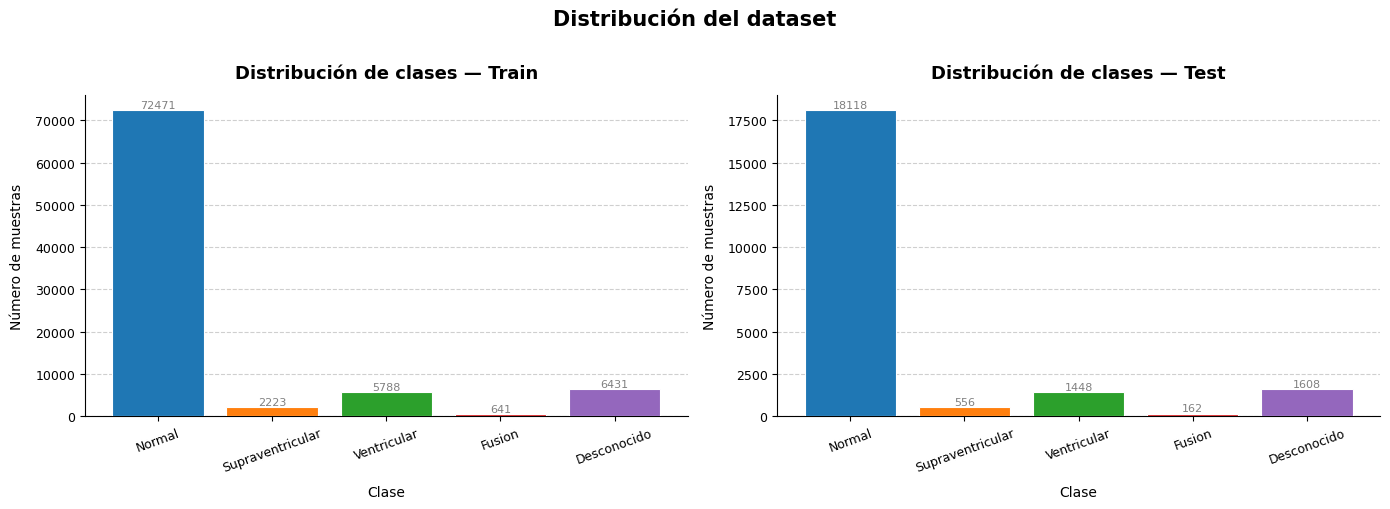

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10.colors

for ax, counts, title in zip(axes, [train_counts, test_counts], ["Train", "Test"]):
    bars = ax.bar([class_names[i] for i in counts.index], counts.values,
                  color=colors[:len(counts)], edgecolor="white", linewidth=0.8, zorder=3)
    ax.set_title(f"Distribución de clases — {title}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Clase", fontsize=10, labelpad=8)
    ax.set_ylabel("Número de muestras", fontsize=10, labelpad=8)
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=8, color="gray")

fig.suptitle("Distribución del dataset", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Podemos ver que tenemos un problema muy serio de desequilibrio de clases, con la clase "Normal" representando el 80% de los datos, mientras que las otras clases tienen una representación mucho menor. Este desequilibrio puede afectar negativamente el rendimiento del modelo, especialmente en la capacidad de detectar las clases minoritarias.

Para minimizar el impacto de este desequilibrio, podríamos considerar técnicas distintas técnicas. Además, es importante evaluar el rendimiento del modelo utilizando métricas adecuadas, como la matriz de confusión, la precisión, la recuperación y el F1-score, en lugar de depender únicamente de la precisión global.

Para mediar con el desbalanceo, utilizaremos dos técnicas y las compararemos. La primera técnica es el submuestreo de la clase mayoritaria, que consiste en reducir el número de muestras de la clase "Normal" para equilibrar el dataset. La segunda técnica es utilizar ``compute_class_weight`` de `sklearn` para asignar pesos a las clases durante el entrenamiento del modelo, lo que permite que el modelo preste más atención a las clases minoritarias sin eliminar datos de la clase mayoritaria.

``` python
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

...

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
```

### Visualización de Señales ECG

Por último, realizamos una visualización de las señales ECG para cada tipo de latido cardíaco. Esto nos permitirá observar las diferencias en las formas de onda entre las clases y entender mejor las características de cada tipo de latido. También nos ayudará a entender que son exactamente los datos con los que estamos trabajando.

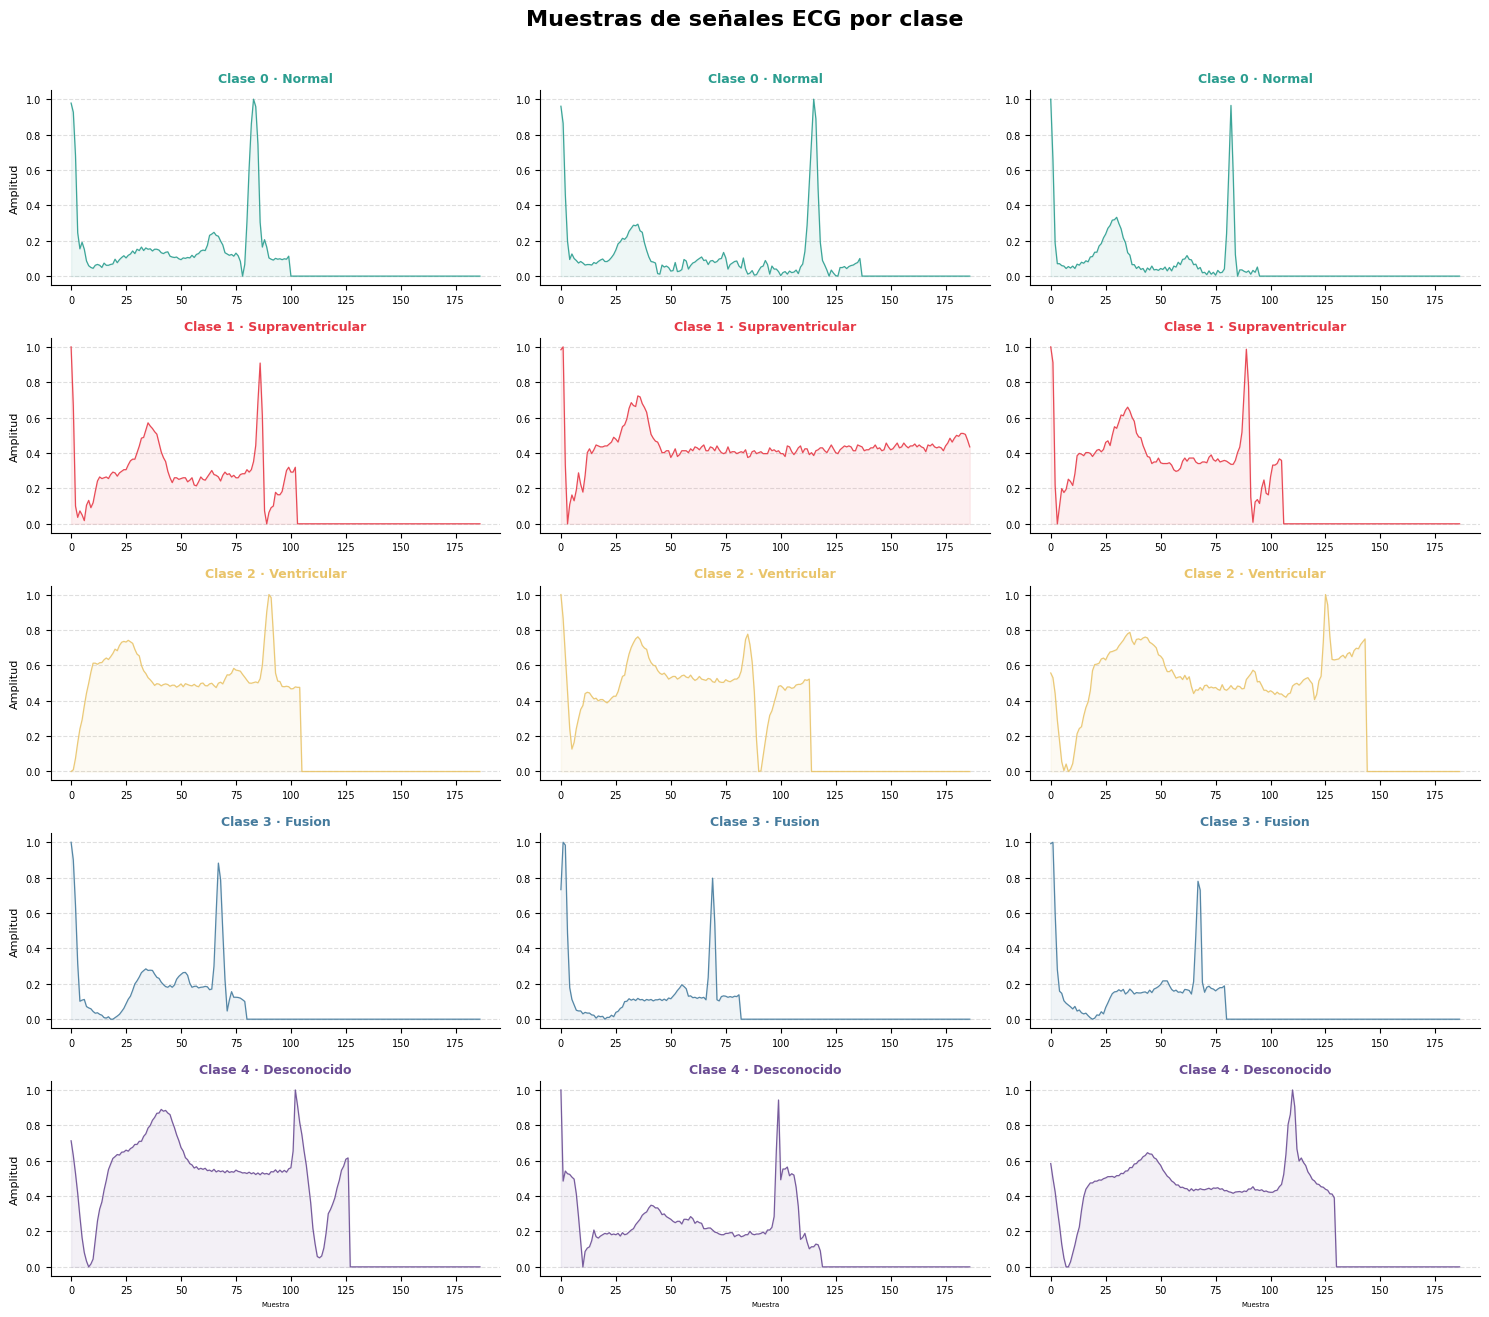

In [91]:
signal_cols = [f"t{i}" for i in range(187)]

palette = ["#2a9d8f", "#e63946", "#e9c46a", "#457b9d", "#6a4c93"]

fig, axes = plt.subplots(5, 3, figsize=(15, 13))
fig.suptitle("Muestras de señales ECG por clase", fontsize=16, fontweight="bold", y=1.01)

for label, ax_row in enumerate(axes):
    samples = data_train[data_train["label"] == label][signal_cols].values
    color = palette[label]
    for ax, sample in zip(ax_row, samples[:3]):
        ax.plot(sample, color=color, linewidth=0.9, alpha=0.9)
        ax.fill_between(range(len(sample)), sample, alpha=0.08, color=color)
        ax.set_title(f"Clase {label} · {class_names[label]}", fontsize=9, fontweight="bold", color=color)
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

for ax in axes[-1]:
    ax.set_xlabel("Muestra", fontsize=5)
for ax_row in axes:
    ax_row[0].set_ylabel("Amplitud", fontsize=8)

plt.tight_layout()
plt.show()

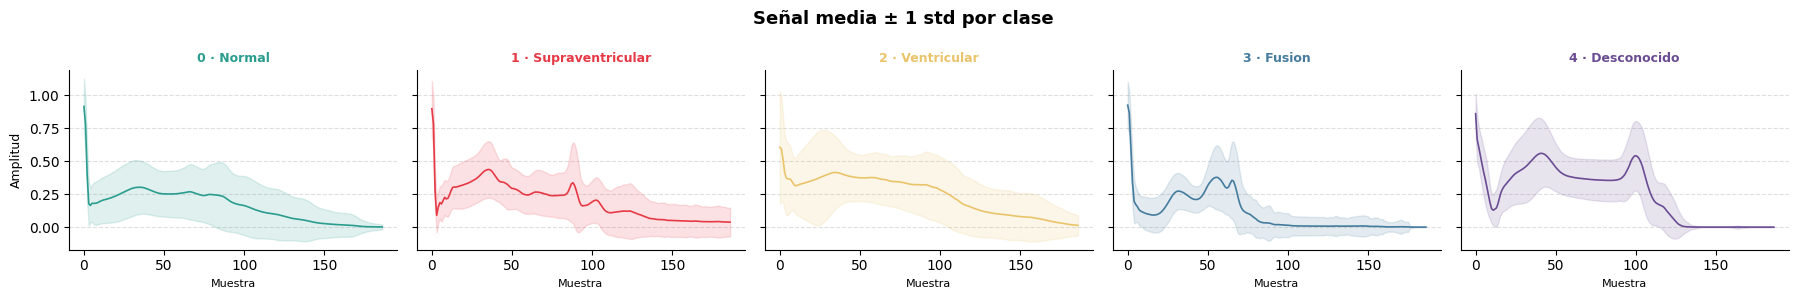

In [92]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
fig.suptitle("Señal media ± 1 std por clase", fontsize=13, fontweight="bold")

for label, ax in enumerate(axes):
    signals = data_train[data_train["label"] == label][signal_cols].values
    mean = signals.mean(axis=0)
    std  = signals.std(axis=0)
    x = np.arange(187)
    color = palette[label]
    ax.plot(mean, color=color, linewidth=1.2)
    ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_title(f"{label} · {class_names[label]}", fontsize=9, fontweight="bold", color=color)
    ax.set_xlabel("Muestra", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Amplitud", fontsize=9)
plt.tight_layout()
plt.show()